# Modelo de Kuramoto: sincronización colectiva

Este cuaderno implementa el modelo de Kuramoto de osciladores acoplados para estudiar la transición de incoherencia a sincronización. La ecuación dinámica es:

$$\dot{\theta}_i = \omega_i + K \cdot R \cdot \sin(\psi - \theta_i)$$

donde $R(t)$ y $\psi(t)$ son el módulo y la fase del parámetro de orden complejo:

$$R(t)\,e^{i\psi(t)} = \frac{1}{N}\sum_{j=1}^N e^{i\theta_j(t)}$$

Vamos a construir el código en bloques: primero la clase que almacena el sistema, luego el integrador numérico, después el barrido de parámetros, y finalmente las visualizaciones.

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit
from scipy.stats import norm
from scipy.stats import t as t_dist
from joblib import Parallel, delayed

## Configuración del estilo de los plots

Definimos una única función que aplica un estilo profesional tipo "paper" a todos los plots. Usa tipografía serif estilo LaTeX, rejilla tenue y ticks hacia adentro según la convención de física. Al llamarla una vez al inicio de cada plot, todos quedan homogéneos.

También definimos el path a la carpeta `figures/` de forma relativa al propio archivo, para que funcione se ejecute desde donde se ejecute.

In [102]:
def setup_plot_style():
    """
    Configura matplotlib con estilo profesional para publicaciones.
    """
    plt.rcParams.update({
        'font.family'       : 'serif',
        'font.serif'        : ['Computer Modern Roman', 'DejaVu Serif'],
        'font.size'         : 11,
        'axes.labelsize'    : 13,
        'axes.titlesize'    : 14,
        'legend.fontsize'   : 10,
        'xtick.labelsize'   : 10,
        'ytick.labelsize'   : 10,
        'axes.linewidth'    : 1.0,
        'axes.grid'         : True,
        'grid.alpha'        : 0.25,
        'grid.linestyle'    : '--',
        'grid.linewidth'    : 0.5,
        'xtick.direction'   : 'in',
        'ytick.direction'   : 'in',
        'xtick.top'         : True,
        'ytick.right'       : True,
        'xtick.major.size'  : 5,
        'ytick.major.size'  : 5,
        'xtick.minor.visible': True,
        'ytick.minor.visible': True,
        'legend.frameon'    : True,
        'legend.framealpha' : 0.95,
        'legend.edgecolor'  : 'black',
        'legend.fancybox'   : False,
        'figure.dpi'        : 100,
        'savefig.dpi'       : 300,
        'savefig.bbox'      : 'tight',
    })

# Path relativo al script: funciona desde cualquier directorio de ejecución
FIGURES_DIR = os.path.join(r'c:\Users\Rafa\Desktop\IMPORTANTE_UNIVERSIDAD\Asignaturas\5to\2doCuatri\SistemasComplejos\Kuramoto', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

def _unique_path(directory, filename):
    """Si el archivo ya existe, añade (1), (2), ... para no sobreescribir."""
    base, ext = os.path.splitext(filename)
    path = os.path.join(directory, filename)
    n = 1
    while os.path.exists(path):
        path = os.path.join(directory, f'{base}({n}){ext}')
        n += 1
    return path

## La clase `KuramotoSystem`

Agrupamos toda la información de una simulación en un único objeto. Esto nos permite pasar un sistema completo como argumento y acceder a sus datos con puntos (`sys.R`, `sys.omega`, etc.), en lugar de manejar listas sueltas.

**Decisión clave de diseño:** las fases no se almacenan completas en el tiempo. Guardar `theta[N, steps+1]` consumiría mucha memoria (8 MB por simulación con N=500, steps=2000) para información que nunca se usa una vez terminada la integración. En su lugar, usamos dos buffers de tamaño N (`theta_curr` y `theta_next`) que se intercambian en cada paso. Así reducimos memoria ~1000x y, como los arrays caben en caché L2/L3 de la CPU, la simulación es también más rápida.

Lo único que sí guardamos a lo largo del tiempo es $R(t)$ y $\psi(t)$, que son vectores 1D (un número por instante) y ocupan poco.

Las `@property` `R_mean` y `R_std` se calculan bajo demanda a partir de $R$, descartando el primer 25% de la simulación para eliminar el transitorio inicial.

In [103]:
class KuramotoSystem:

    def __init__(self, N: int, steps: int, dt: float):
        self.N     = N          # Número de osciladores
        self.steps = steps      # Número de pasos temporales
        self.dt    = dt         # Paso de tiempo

        # Parámetro de orden R(t) y fase media ψ(t), shape (steps+1,)
        self.R   = np.zeros(steps + 1, dtype=np.float64)
        self.psi = np.zeros(steps + 1, dtype=np.float64)

        # Frecuencias naturales ω, shape (N,). Estáticas (no cambian en t)
        self.omega = np.zeros(N, dtype=np.float64)

        # Buffers de fases para Euler: actual y siguiente
        self.theta_curr = np.zeros(N, dtype=np.float64)
        self.theta_next = np.zeros(N, dtype=np.float64)

    def initialize(self, sigma: float = 1.0):
        """omega ~ N(0, sigma), theta inicial ~ U(-π, π)."""
        self.omega      = np.random.normal(0, sigma, self.N)
        self.theta_curr = np.random.uniform(-np.pi, np.pi, self.N)

    def run(self, K: float):
        """Ejecuta la integración. Numba modifica los arrays in-place."""
        _integrar(self.theta_curr, self.theta_next,
                  self.omega, K, self.dt, self.steps, self.R, self.psi)

    @property
    def R_mean(self):
        """⟨R⟩ descartando el primer 25% (transitorio)."""
        n_trans = self.steps // 4
        return np.mean(self.R[n_trans:])

    @property
    def R_std(self) -> float:
        """σ_R: mide la metaestabilidad (pico en Kc)."""
        n_trans = self.steps // 4
        return float(np.std(self.R[n_trans:]))

## La función de integración con Numba

Numba compila esta función a código máquina, acelerándola ~100x respecto a Python puro. La dejamos **fuera de la clase** porque Numba no entiende `self` (es un objeto Python genérico). El patrón estándar es: la clase organiza los datos, la función Numba hace el cómputo pesado.

**Optimización importante:** en lugar de hacer el doble bucle $O(N^2)$ de la ecuación original $\sum_j \sin(\theta_j - \theta_i)$, primero calculamos $R$ y $\psi$ y usamos la forma simplificada $K \cdot R \cdot \sin(\psi - \theta_i)$. Pasamos de $O(N^2)$ a $O(N)$ por paso temporal.

**Sobre el paralelismo:** quitamos `parallel=True` dentro de esta función porque paralelizar a nivel de oscilador para N pequeño tiene más overhead que ganancia. En su lugar, paralelizamos a nivel de *runs* (simulaciones independientes), que es mucho más eficiente.

El decorador `cache=True` guarda el código compilado en disco para que la próxima ejecución del script sea instantánea.

In [104]:
@njit(fastmath=True, cache=True)
def _integrar(theta_curr, theta_next, omega, K, dt, steps, R, psi):
    N = theta_curr.shape[0]

    for t in range(steps):

        # R(t) y ψ(t) a partir de R·e^(iψ) = (1/N) Σ e^(iθ_j)
        re, im = 0.0, 0.0
        for j in range(N):
            re += math.cos(theta_curr[j])
            im += math.sin(theta_curr[j])

        R[t]   = math.sqrt(re**2 + im**2) / N
        psi[t] = math.atan2(im, re)

        # Euler: θ̇_i = ω_i + K·R·sin(ψ - θ_i)
        for i in range(N):
            theta_next[i] = theta_curr[i] + dt * (omega[i] + K * R[t] * math.sin(psi[t] - theta_curr[i]))

        # Swap de buffers: ahora theta_curr contiene t+1
        for i in range(N):
            theta_curr[i] = theta_next[i]

    # Último paso: calculamos R y ψ en t = steps
    re, im = 0.0, 0.0
    for j in range(N):
        re += math.cos(theta_curr[j])
        im += math.sin(theta_curr[j])
    R[steps]   = math.sqrt(re**2 + im**2) / N
    psi[steps] = math.atan2(im, re)

## Wrapper de simulación

`Simulacion_Kuramoto` encadena los tres pasos típicos: crear el sistema, inicializarlo y ejecutarlo. Devuelve el objeto completo para poder acceder a todos sus datos.

`_una_simulacion_indexada` es una función auxiliar que necesita joblib para el paralelismo. Devuelve solo los observables de interés junto con sus índices $(i, j)$ para poder reconstruir la matriz de resultados después, sin tener que mandar el objeto completo entre procesos.

In [105]:
def Simulacion_Kuramoto(N, K, sigma, dt, t_max):
    num_pasos = int(t_max / dt)
    sys = KuramotoSystem(N=N, steps=num_pasos, dt=dt)
    sys.initialize(sigma=sigma)
    sys.run(K=K)
    return sys


def _una_simulacion_indexada(i, j, N, K, sigma, dt, t_max):
    """Ejecuta una simulación y devuelve su posición (i,j) en la matriz."""
    sys = Simulacion_Kuramoto(N, K, sigma, dt, t_max)
    return (i, j, sys.R_mean, sys.R_std)

## Acoplamiento crítico Kc

Para una distribución gaussiana de frecuencias, la teoría predice $K_c = \sigma \sqrt{8/\pi}$ en el límite $N \to \infty$.

Experimentalmente, estimamos $K_c$ como el $K$ donde $\sigma_R$ es máximo, porque en la transición el sistema alterna entre coherencia e incoherencia, y esa alternancia se traduce en fluctuaciones grandes del parámetro de orden.

In [106]:
def Kc_teorica(sigma):
    """Kc teórica para distribución gaussiana: Kc = σ·√(8/π)."""
    return sigma * math.sqrt(8 / math.pi)


def Kc_experimental(K_values, R_stds):
    """Kc como argmax de σ_R: máxima variabilidad = transición."""
    return K_values[np.argmax(R_stds)]

## Muestreo no uniforme de K

La curva $\langle R \rangle(K)$ es casi constante lejos de $K_c$ y cambia rápidamente cerca. Si usamos `np.linspace` desperdiciamos puntos en las zonas planas y nos faltan en la transición.

La solución es generar puntos con densidad gaussiana centrada en $K_c$: usamos la inversa de la CDF para proyectar puntos uniformes del eje Y al eje X, quedando densos donde la gaussiana es alta (centro) y dispersos en los extremos.

El centro lo desplazamos ligeramente ($1.05 \cdot K_c$) porque la transición real suele quedar un pelín por encima de la $K_c$ teórica por efectos de tamaño finito.

In [107]:
def K_values_gaussiano(num_K, K_min, K_max, Kc, width_factor=0.3):
    """Genera num_K valores de K con densidad gaussiana centrada en ~Kc."""
    K_center = 1.05 * Kc
    sigma_K  = width_factor * Kc

    # Invertimos la CDF: uniforme en [u_min, u_max] → K no uniforme
    u_min = norm.cdf(K_min, loc=K_center, scale=sigma_K)
    u_max = norm.cdf(K_max, loc=K_center, scale=sigma_K)

    u_values = np.linspace(u_min, u_max, num_K)
    K_values = norm.ppf(u_values, loc=K_center, scale=sigma_K)
    return K_values

def K_values_curva(num_K, K_min, K_max, Kc, n_fine=10000):
    """Genera num_K valores de K equiespaciados en longitud de arco
    de la curva teórica R(K) = sqrt((K - Kc) / K), con ejes normalizados."""
    K_fine = np.linspace(K_min, K_max, n_fine)

    R_fine = np.where(K_fine > Kc, np.sqrt((K_fine - Kc) / K_fine), 0.0)

    # Normalizar ambos ejes a [0, 1] para que la geometría sea visual
    K_norm = (K_fine - K_min) / (K_max - K_min)
    R_max  = np.max(R_fine) if np.max(R_fine) > 0 else 1.0
    R_norm = R_fine / R_max

    dK_n = np.diff(K_norm)
    dR_n = np.diff(R_norm)

    ds = np.sqrt(dK_n**2 + dR_n**2)
    s_cumul = np.concatenate([[0.0], np.cumsum(ds)])

    s_uniform = np.linspace(0, s_cumul[-1], num_K)
    K_values = np.interp(s_uniform, s_cumul, K_fine)
    return K_values


def K_values_curva_tstudent(num_K, K_min, K_max, Kc, width_factor, n_fine, df):
    """Genera num_K valores de K distribuidos sobre la curva teórica
    R(K) = sqrt((K - Kc) / K), con densidad t-Student centrada en ~Kc."""
    K_center = 1.1 * Kc
    sigma_K  = width_factor * Kc
    K_fine = np.linspace(K_min, K_max, n_fine)
    R_fine = np.where(K_fine > Kc,
                      np.sqrt((K_fine - Kc) / K_fine),
                      0.0)
    # Normalizar ambos ejes a [0, 1]
    K_norm = (K_fine - K_min) / (K_max - K_min)
    R_max  = np.max(R_fine) if np.max(R_fine) > 0 else 1.0
    R_norm = R_fine / R_max
    dK_n = np.diff(K_norm)
    dR_n = np.diff(R_norm)
    ds = np.sqrt(dK_n**2 + dR_n**2)
    s_cumul = np.concatenate([[0.0], np.cumsum(ds)])
    # Peso t-Student en cada segmento (colas más pesadas que gaussiana)
    K_mid = 0.5 * (K_fine[:-1] + K_fine[1:])
    w = t_dist.pdf(K_mid, df=df, loc=K_center, scale=sigma_K)
    w_ds = w * ds
    F = np.concatenate([[0.0], np.cumsum(w_ds)])
    F /= F[-1]
    u_values = np.linspace(0, 1, num_K)
    s_samples = np.interp(u_values, F, s_cumul)
    K_values  = np.interp(s_samples, s_cumul, K_fine)
    return K_values



## Barrido paramétrico completo

Esta es la función central. Ejecuta simulaciones para cada combinación $(\sigma, K)$ y para cada una lanza varios *runs* independientes para tener estadística.

**Clave de la velocidad:** generamos **todas las tareas del barrido** en una lista única, y lanzamos `Parallel` UNA sola vez. Así joblib crea el pool de workers una vez y lo reutiliza para todas las tareas, en lugar de crearlo y destruirlo para cada par $(\sigma, K)$. Esto evita gran parte del overhead de paralelización.

Los resultados los devuelven los workers con su índice $(i, j)$, lo que nos permite agruparlos después en matrices $(n_{\sigma}, n_K)$.

La barra de progreso `verbose=10` de joblib nos muestra cuántas tareas lleva completadas cada cierto porcentaje.

In [108]:
def barrido_completo(N, sigma_values, num_K, K_min, K_max, num_runs, dt, t_max, width_factor, n_fine, n_jobs=-1):
    n_sigmas = len(sigma_values)

    # Matrices de resultados
    K_values_per_sigma = np.zeros((n_sigmas, num_K))
    R_means            = np.zeros((n_sigmas, num_K))
    R_stds             = np.zeros((n_sigmas, num_K))
    R_mean_stds        = np.zeros((n_sigmas, num_K))

    # Pre-calculamos los K_values para cada sigma (cada uno centrado en su Kc)
    for i, sigma in enumerate(sigma_values):
        Kc = Kc_teorica(sigma)
        # K_values_per_sigma[i] = K_values_gaussiano(num_K, K_min, K_max, Kc, width_factor)
        # K_values_per_sigma[i] = K_values_curva(num_K, K_min, K_max, Kc, n_fine)
        K_values_per_sigma[i] = K_values_curva_tstudent(num_K, K_min, K_max, Kc, width_factor, n_fine, df=2)

    # Generamos TODAS las tareas de golpe, con sus índices (i, j)
    tareas = []
    for i, sigma in enumerate(sigma_values):
        for j, K in enumerate(K_values_per_sigma[i]):
            for _ in range(num_runs):
                tareas.append((i, j, N, K, sigma, dt, t_max))

    print(f"Lanzando {len(tareas)} simulaciones en paralelo...")

    # UN solo Parallel para todo: el pool se reutiliza
    resultados = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(_una_simulacion_indexada)(*tarea) for tarea in tareas
    )

    # Agregamos los resultados por (i, j)
    means_por_punto = {}
    stds_por_punto  = {}
    for (i, j, r_mean, r_std) in resultados:
        means_por_punto.setdefault((i, j), []).append(r_mean)
        stds_por_punto .setdefault((i, j), []).append(r_std)

    for (i, j), means in means_por_punto.items():
        R_means[i, j]     = np.mean(means)
        R_stds[i, j]      = np.mean(stds_por_punto[(i, j)])
        R_mean_stds[i, j] = np.std(means)

    return K_values_per_sigma, R_means, R_stds, R_mean_stds

## Visualización

Dos figuras principales:

1. **$\langle R \rangle$ vs $K$**: la curva de sincronización. Cada $\sigma$ tiene su propia curva, con bandas de error (desviación estándar entre runs) y una línea vertical punteada en su $K_c$ teórica.

2. **$\sigma_R$ vs $K$**: la variabilidad del parámetro de orden. Su pico marca el $K_c$ experimental.

Ambos plots usan la paleta viridis recortada (evitando amarillo puro y morado oscuro, poco legibles) y muestran una caja con los parámetros de simulación como contexto.

In [109]:
def plot_R_vs_K(K_values_per_sigma, sigma_values, R_means, R_mean_stds,
                N, t_max, num_K, num_runs, guardar=False):
    setup_plot_style()
    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(sigma_values)))

    for i, sigma in enumerate(sigma_values):
        Kc_th = Kc_teorica(sigma)

        # Banda de error ±1σ entre runs
        ax.fill_between(K_values_per_sigma[i],
                        R_means[i] - R_mean_stds[i],
                        R_means[i] + R_mean_stds[i],
                        color=colors[i], alpha=0.2)

        ax.plot(K_values_per_sigma[i], R_means[i],
                marker='o', markersize=4, linewidth=1.5,
                color=colors[i],
                label=fr'$\sigma = {sigma:.2f}$   $K_c^{{\mathrm{{th}}}} = {Kc_th:.2f}$')

        ax.axvline(Kc_th, color=colors[i], linestyle='--', linewidth=1.0, alpha=0.6)

    ax.set_xlabel(r'Acoplamiento $K$')
    ax.set_ylabel(r'Parámetro de orden $\langle R \rangle$')
    ax.set_title(r'Transición de sincronización en el modelo de Kuramoto')
    ax.set_xlim(left=0)
    ax.set_ylim(-0.02, 1.02)

    ax.text(0.98, 0.05,
            fr'$N = {N}$, $\langle \mathrm{{runs}} \rangle = {num_runs}$',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, style='italic', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.7))

    ax.legend(loc='lower right', title=r'Líneas: $K_c$ teórica')

    if guardar:
        fname = f'R_vs_K_N{N}_t{t_max}_K{num_K}_Runs{num_runs}.png'
        fig.savefig(_unique_path(FIGURES_DIR, fname))
    plt.show()


def plot_sigmaR_vs_K(K_values_per_sigma, sigma_values, R_stds,
                     N, t_max, num_K, num_runs, guardar=False):
    setup_plot_style()
    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(sigma_values)))

    for i, sigma in enumerate(sigma_values):
        Kc_exp = K_values_per_sigma[i, np.argmax(R_stds[i])]

        ax.plot(K_values_per_sigma[i], R_stds[i],
                marker='o', markersize=4, linewidth=1.5,
                color=colors[i],
                label=fr'$\sigma = {sigma:.2f}$   $K_c^{{\mathrm{{exp}}}} = {Kc_exp:.2f}$')

        ax.axvline(Kc_exp, color=colors[i], linestyle=':', linewidth=1.2, alpha=0.8)

    ax.set_xlabel(r'Acoplamiento $K$')
    ax.set_ylabel(r'Desviación estándar $\sigma_R$')
    ax.set_title(r'Metaestabilidad: fluctuaciones del parámetro de orden')
    ax.set_xlim(left=0)

    ax.text(0.98, 0.95,
            fr'$N = {N}$, $\langle \mathrm{{runs}} \rangle = {num_runs}$',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, style='italic', alpha=0.7,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.7))

    ax.legend(loc='upper right', title=r'Líneas: $K_c$ experimental')

    if guardar:
        fname = f'sigmaR_vs_K_N{N}_t{t_max}_K{num_K}_Runs{num_runs}.png'
        fig.savefig(_unique_path(FIGURES_DIR, fname))
    plt.show()


## Main: ejecución y reporte

Lanzamos el barrido completo y, además de los plots, generamos una tabla comparando $K_c$ teórica y experimental para cada $\sigma$, junto con la variabilidad media entre runs. Este último dato nos dice si el número de runs es suficiente: si la variabilidad es $\ll 0.01$, la estadística es excelente; si supera $0.02$, convendría aumentar `num_runs` o `t_max`.

El bloque `if __name__ == "__main__"` es importante cuando se usa joblib en Windows/macOS: sin él, los workers re-importarían el módulo y ejecutarían todo otra vez, causando un bucle infinito de procesos.

Barrido: 3 sigmas × 100 K × 15 runs = 4500 simulaciones

Lanzando 4500 simulaciones en paralelo...


C:\Users\Rafa\AppData\Local\Temp\ipykernel_16164\203456392.py:44: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt((K_fine - Kc) / K_fine),
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 113 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 149 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 

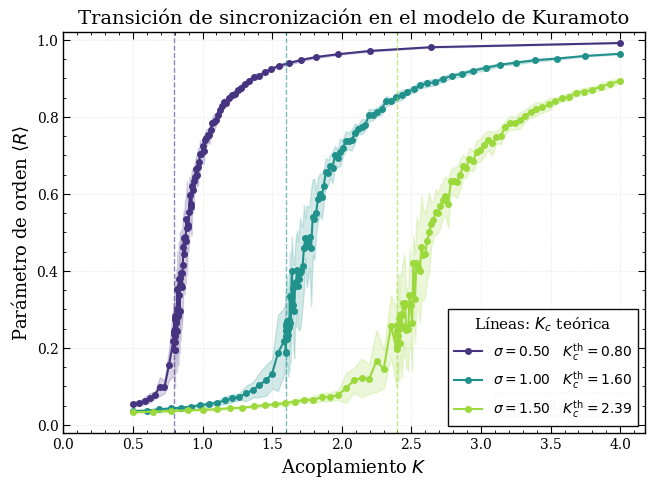

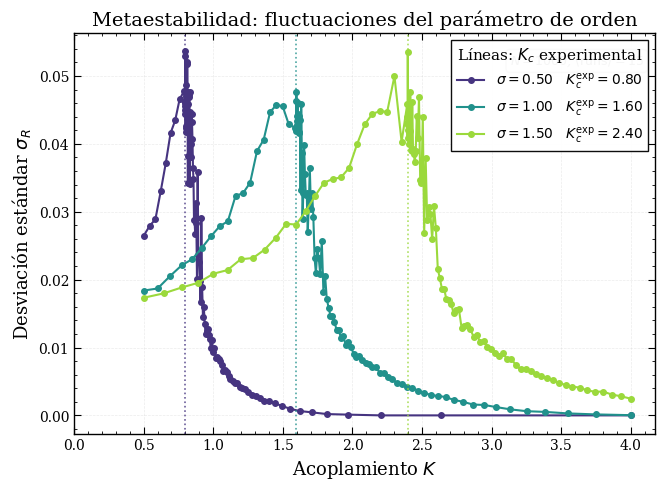


     σ |  Kc teórica | Kc experimental |  <σ(R_mean)>
------------------------------------------------------------
  0.50 |       0.798 |           0.800 |      0.05642
  1.00 |       1.596 |           1.597 |      0.05057
  1.50 |       2.394 |           2.397 |      0.05298

<σ(R_mean)> global = 0.05332


In [110]:
def main():
    # Parámetros del sistema
    N     = 1000
    dt    = 0.01
    t_max = 150.0

    # Parámetros del barrido
    num_K        = 100
    num_sigmas   = 3
    num_runs     = 15
    width_factor = 0.6
    n_fine       = 10000

    # Rangos
    K_min,     K_max     = 0.5, 4.0
    sigma_min, sigma_max = 0.5, 1.5

    sigma_values = np.linspace(sigma_min, sigma_max, num_sigmas)

    print(f"Barrido: {num_sigmas} sigmas × {num_K} K × {num_runs} runs "
          f"= {num_sigmas * num_K * num_runs} simulaciones\n")

    K_values_per_sigma, R_means, R_stds, R_mean_stds = barrido_completo(N, sigma_values, num_K, K_min, K_max, num_runs, dt, t_max, width_factor, n_fine)

    plot_R_vs_K(K_values_per_sigma, sigma_values, R_means, R_mean_stds,
                N, t_max, num_K, num_runs, guardar=True)
    plot_sigmaR_vs_K(K_values_per_sigma, sigma_values, R_stds,
                     N, t_max, num_K, num_runs, guardar=True)

    # Tabla comparativa
    print("\n" + "="*60)
    print(f"{'σ':>6} | {'Kc teórica':>11} | {'Kc experimental':>15} | {'<σ(R_mean)>':>12}")
    print("-"*60)
    for i, sigma in enumerate(sigma_values):
        Kc_th            = Kc_teorica(sigma)
        Kc_exp           = K_values_per_sigma[i, np.argmax(R_stds[i])]
        mean_variability = np.mean(R_mean_stds[i])
        print(f"{sigma:>6.2f} | {Kc_th:>11.3f} | {Kc_exp:>15.3f} | {mean_variability:>12.5f}")
    print("="*60)

    global_variability = np.mean(R_mean_stds)
    print(f"\n<σ(R_mean)> global = {global_variability:.5f}")


if __name__ == "__main__":
    main()
